# This notebook will be used to create a data preprocessing pipeline

## 1. Extracting Data and initial visualization

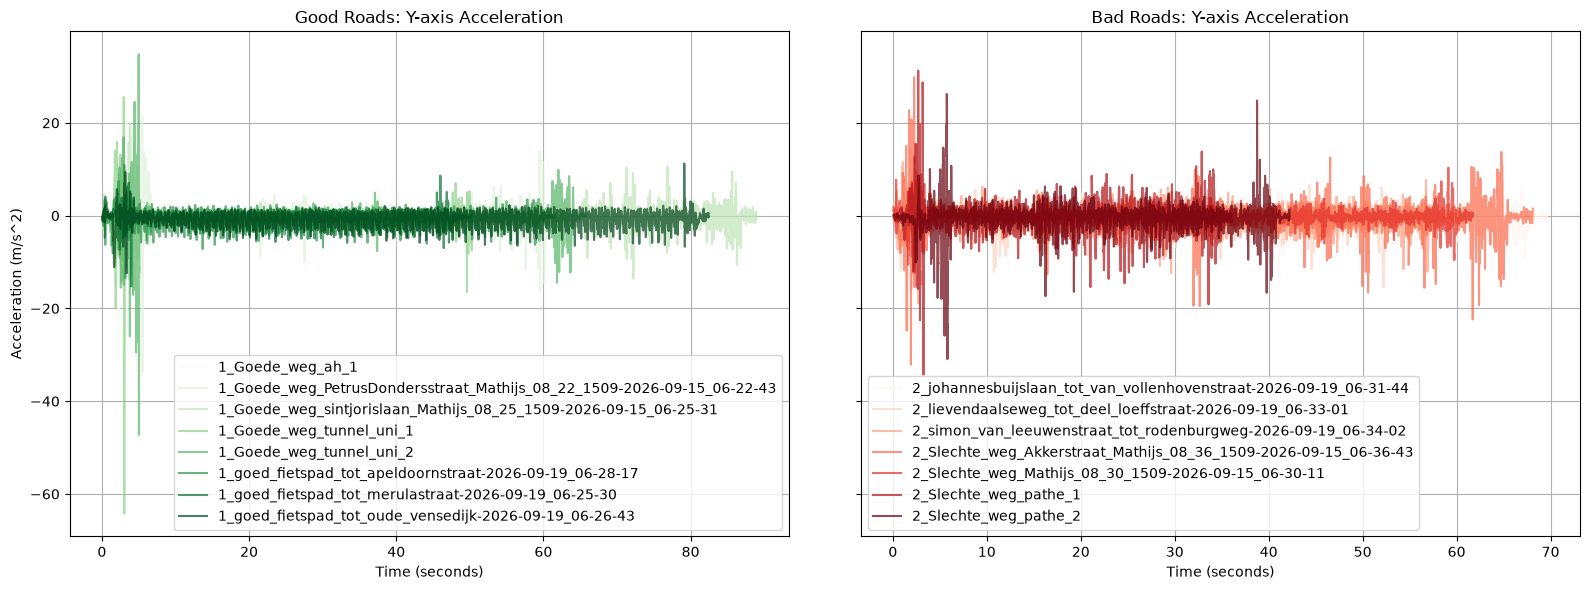

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
os.environ["OMP_NUM_THREADS"] = "2"

# Automatically discover all good roads (starting with "1") and bad roads (starting with "2")
good_paths = glob.glob("data/1_*/**/Accelerometer.csv", recursive=True)
if not good_paths:
    good_paths = glob.glob("data/1_*/Accelerometer.csv")

bad_paths = glob.glob("data/2_*/**/Accelerometer.csv", recursive=True)
if not bad_paths:
    bad_paths = glob.glob("data/2_*/Accelerometer.csv")

# Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Generate distinct shades of green for good roads dynamically
good_colors = plt.cm.Greens(
    [i / max(1, len(good_paths) - 1) for i in range(len(good_paths))]
)

# Plot all good road recordings
for path, color in zip(good_paths, good_colors):
    df = pd.read_csv(path)
    # Extract folder name to use as a dynamic label
    label = path.split(os.sep)[-2]
    ax1.plot(df['seconds_elapsed'], df['y'], label=label, color=color, alpha=0.7)

ax1.set_title("Good Roads: Y-axis Acceleration")
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Acceleration (m/s^2)")
ax1.legend()
ax1.grid(True)

# Generate distinct shades of red for bad roads dynamically
bad_colors = plt.cm.Reds(
    [i / max(1, len(bad_paths) - 1) for i in range(len(bad_paths))]
)

# Plot all bad road recordings
for path, color in zip(bad_paths, bad_colors):
    df = pd.read_csv(path)
    label = path.split(os.sep)[-2]
    ax2.plot(df['seconds_elapsed'], df['y'], label=label, color=color, alpha=0.7)

ax2.set_title("Bad Roads: Y-axis Acceleration")
ax2.set_xlabel("Time (seconds)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 2. Cut and Synchronise Data

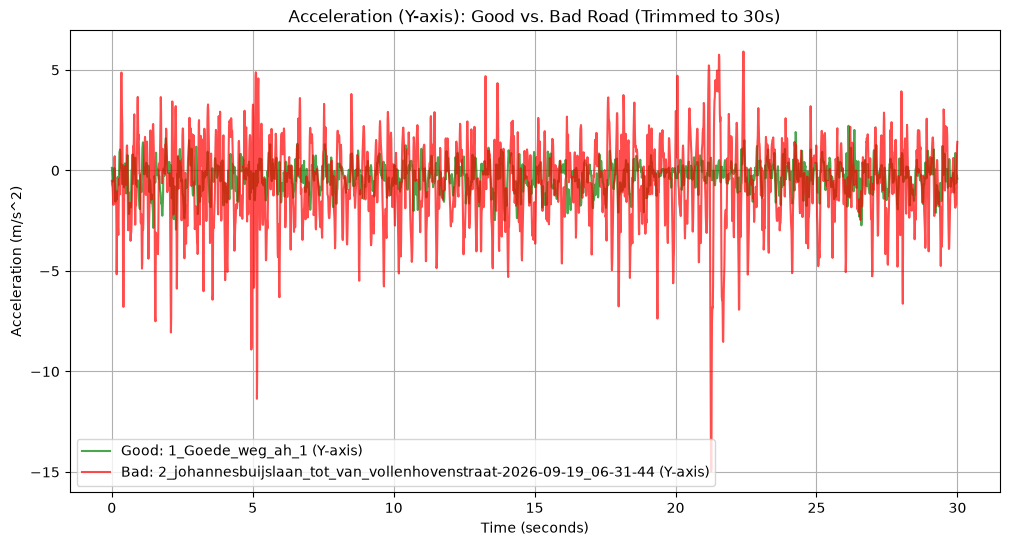

In [2]:
def trim_to_30s(df):
    """Trims dataframe symmetrically to a duration of 30 seconds."""
    start_time = df['seconds_elapsed'].min()
    end_time = df['seconds_elapsed'].max()
    total_duration = end_time - start_time
    
    if total_duration > 30:
        trim_amount = (total_duration - 30) / 2
        new_start = start_time + trim_amount
        new_end = end_time - trim_amount
        
        # Filter rows within the 30-second window and reset elapsed time from 0
        df_trimmed = df[(df['seconds_elapsed'] >= new_start) & (df['seconds_elapsed'] <= new_end)].copy()
        df_trimmed['seconds_elapsed'] = df_trimmed['seconds_elapsed'] - new_start
        return df_trimmed
    return df

# Process and trim all discovered good road recordings dynamically
good_roads_trimmed = {}
for path in good_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    good_roads_trimmed[key] = trim_to_30s(df)

# Process and trim all discovered bad road recordings dynamically
bad_roads_trimmed = {}
for path in bad_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    bad_roads_trimmed[key] = trim_to_30s(df)

# Plotting example: Y-axis comparison of a sample good and bad road after trimming
plt.figure(figsize=(12, 6))

if good_roads_trimmed:
    first_good_key = list(good_roads_trimmed.keys())[0]
    df_g = good_roads_trimmed[first_good_key]
    plt.plot(df_g['seconds_elapsed'], df_g['y'], label=f'Good: {first_good_key} (Y-axis)', color='green', alpha=0.7)

if bad_roads_trimmed:
    first_bad_key = list(bad_roads_trimmed.keys())[0]
    df_b = bad_roads_trimmed[first_bad_key]
    plt.plot(df_b['seconds_elapsed'], df_b['y'], label=f'Bad: {first_bad_key} (Y-axis)', color='red', alpha=0.7)

plt.title('Acceleration (Y-axis): Good vs. Bad Road (Trimmed to 30s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Windowing, Band-Pass Filter and Statistics

In [3]:
import numpy as np
from scipy.signal import butter, lfilter
from scipy.stats import skew, kurtosis

# 1. Bandpass filter definitions
def butter_bandpass(lowcut, highcut, fs, order=4):
    """Design a Butterworth bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Apply the bandpass filter to a data array."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

# 2. Windowing and Feature Extraction function (including Skewness & Kurtosis)
def create_windows_and_filter(df, window_size_sec=2.0, overlap=0.5, fs=100.0):
    """Apply sliding windows and extract statistical features from the Y-axis."""
    df_filtered = df.copy()
    # Apply bandpass filter to the Y-axis
    df_filtered['y_filtered'] = bandpass_filter(df['y'], lowcut=0.5, highcut=20.0, fs=fs)
    
    window_size_samples = int(window_size_sec * fs)
    step_size = int(window_size_samples * (1 - overlap))
    
    features_list = []
    
    for start in range(0, len(df_filtered) - window_size_samples, step_size):
        window = df_filtered.iloc[start:start + window_size_samples]
        sig = window['y_filtered']
        
        # Extract features per window
        feat = {
            'mean': sig.mean(),
            'std': sig.std(),
            'rms': np.sqrt(np.mean(sig**2)),
            'peak_to_peak': sig.max() - sig.min(),
            'iqr': np.percentile(sig, 75) - np.percentile(sig, 25),
            'skewness': skew(sig),
            'kurtosis': kurtosis(sig)
        }
        features_list.append(feat)
        
    return pd.DataFrame(features_list)

# 3. Process ALL trimmed good roads and combine them into a single master dataframe
all_good_features = []
for key, df_trimmed in good_roads_trimmed.items():
    feat_df = create_windows_and_filter(df_trimmed)
    feat_df['source'] = key
    all_good_features.append(feat_df)

features_good = pd.concat(all_good_features, ignore_index=True)

# 4. Process ALL trimmed bad roads and combine them into a single master dataframe
all_bad_features = []
for key, df_trimmed in bad_roads_trimmed.items():
    feat_df = create_windows_and_filter(df_trimmed)
    feat_df['source'] = key
    all_bad_features.append(feat_df)

features_bad = pd.concat(all_bad_features, ignore_index=True)

# 5. Display summary results
print(f"Total feature windows generated for good roads: {len(features_good)}")
print(f"Total feature windows generated for bad roads: {len(features_bad)}")
print("\nFeature sample preview (Good roads):\n", features_good.head(3))

Total feature windows generated for good roads: 232
Total feature windows generated for bad roads: 203

Feature sample preview (Good roads):
        mean       std       rms  peak_to_peak       iqr  skewness  kurtosis  \
0  0.049653  0.808794  0.808296      3.658493  1.092390  0.302002 -0.435841   
1  0.006411  0.944952  0.942608      4.023340  1.438405  0.233579 -0.786159   
2 -0.035088  0.830046  0.828711      3.944835  1.064213 -0.098178 -0.296823   

             source  
0  1_Goede_weg_ah_1  
1  1_Goede_weg_ah_1  
2  1_Goede_weg_ah_1  


## 4. Visualization of Statistics

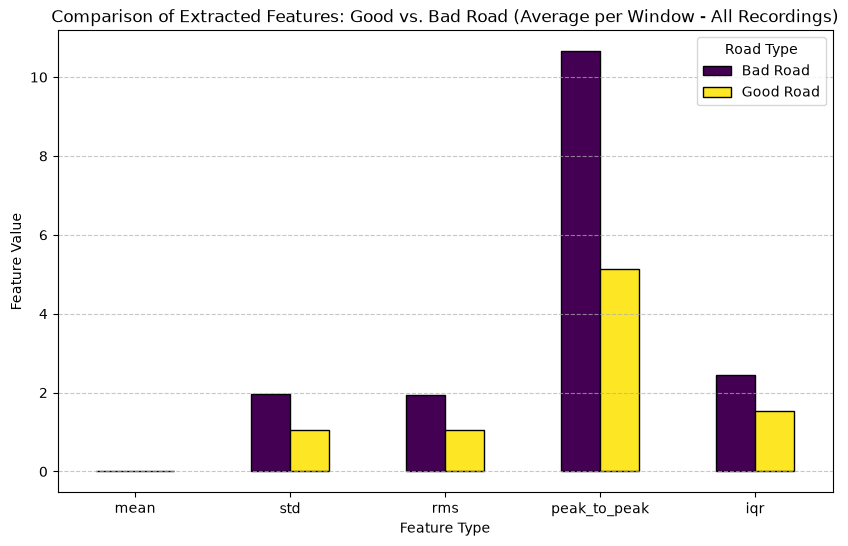

In [4]:
# Prepare copies of our master feature dataframes
features_good_viz = features_good.copy()
features_bad_viz = features_bad.copy()

# Add a road type label to distinguish between datasets
features_good_viz['road_type'] = 'Good Road'
features_bad_viz['road_type'] = 'Bad Road'

# Combine both datasets into a single dataframe for easy comparison
df_combined = pd.concat([features_good_viz, features_bad_viz], ignore_index=True)

# Select the feature columns we want to compare across road types
feature_cols = ['mean', 'std', 'rms', 'peak_to_peak', 'iqr']

# Calculate the average value for each feature per road type across all recordings
mean_comparison = df_combined.groupby('road_type')[feature_cols].mean()

# Create a grouped bar chart to visualize the differences
ax = mean_comparison.T.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title('Comparison of Extracted Features: Good vs. Bad Road (Average per Window - All Recordings)')
plt.ylabel('Feature Value')
plt.xlabel('Feature Type')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Road Type')
plt.show()

### Preparing the Dataset and Defining Features

This step merges the feature datasets for good and bad roads into a single master dataframe. Binary class labels (`target`) are assigned to distinguish between road conditions: `0` represents a good road and `1` represents a bad road. 

The feature set consists of the seven statistical metrics extracted from the accelerometer sliding windows (`mean`, `std`, `rms`, `peak_to_peak`, `iqr`, `skewness`, and `kurtosis`). Furthermore, the `source` column is designated as the group variable for cross-validation to prevent data leakage by keeping individual trips entirely separated between training and test sets.

In [5]:
# Kopieer en label de data
df_ml_good = features_good.copy()
df_ml_bad = features_bad.copy()

df_ml_good['target'] = 0  # Goede weg = 0
df_ml_bad['target'] = 1   # Slechte weg = 1

# Samenvoegen tot één master dataframe voor ML
df_ml = pd.concat([df_ml_good, df_ml_bad], ignore_index=True)

# Definieer welke kolommen je als features wilt gebruiken
feature_cols = ['mean', 'std', 'rms', 'peak_to_peak', 'iqr', 'skewness', 'kurtosis']

X = df_ml[feature_cols]
y = df_ml['target']
groups = df_ml['source']  # Nodig voor  cross-validation

print(f"Dataset vorm (X): {X.shape}")
print(f"Aantal unieke ritten (groups): {groups.nunique()}")

Dataset vorm (X): (435, 7)
Aantal unieke ritten (groups): 15


### Data Splitting and Feature Scaling

This step sets up a robust cross-validation strategy using `GroupKFold` with 5 splits based on the `source` column (individual trips). This ensures that data from the same trip never leaks across both the training and testing sets. 

The first fold is extracted to serve as the standard train/test split for training and evaluating the machine learning models. Additionally, a `StandardScaler` is applied to normalize the feature matrices (`X_train` and `X_test`), scaling them to have a mean of 0 and a standard deviation of 1, which is essential for distance-based algorithms.

In [6]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

# GroupKFold met 5 folds (groupKFold zorgt ervoor dat samples van dezelfde rit niet in zowel train als test set zitten)
gkf = GroupKFold(n_splits=5)

# Haal de eerste fold op als onze standaard train/test split voor latere modellen
train_idx, test_idx = next(gkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Feature scaling (optioneel, voor sommige modellen zoals SVM of Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Aantal samples in Train set: {len(X_train)} (Ritten in train: {df_ml.iloc[train_idx]['source'].nunique()})")
print(f"Aantal samples in Test set: {len(X_test)} (Ritten in test: {df_ml.iloc[test_idx]['source'].nunique()})")

Aantal samples in Train set: 348 (Ritten in train: 12)
Aantal samples in Test set: 87 (Ritten in test: 3)


### Model Evaluation and Visualization Function

This step defines a reusable evaluation function (`evaluate_model`) to assess the performance of trained machine learning models. It generates predictions on the test set and calculates the overall accuracy alongside a detailed classification report containing precision, recall, and f1-score for both classes (`Good Road` and `Bad Road`). Additionally, it plots a visually clear confusion matrix using a seaborn heatmap to show the distribution of correct and incorrect predictions.

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, X_te, y_te, model_name="Model"):
    """Evalueer een getraind model en print de resultaten overzichtelijk."""
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    print(f"--- Evaluatie voor: {model_name} ---")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['Good Road (0)', 'Bad Road (1)']))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

### Training and Evaluating the Random Forest Classifier

This step trains a Random Forest classifier using the extracted feature set and evaluates its performance with the previously defined evaluation function. Since tree-based models are scale-invariant, the unscaled training and test sets are used. The resulting accuracy and confusion matrix provide clear insights into the model's capability to correctly classify good and bad road conditions.

--- Evaluatie voor: Random Forest ---
Accuracy: 0.8046

Classification Report:
               precision    recall  f1-score   support

Good Road (0)       0.66      0.86      0.75        29
 Bad Road (1)       0.92      0.78      0.84        58

     accuracy                           0.80        87
    macro avg       0.79      0.82      0.79        87
 weighted avg       0.83      0.80      0.81        87



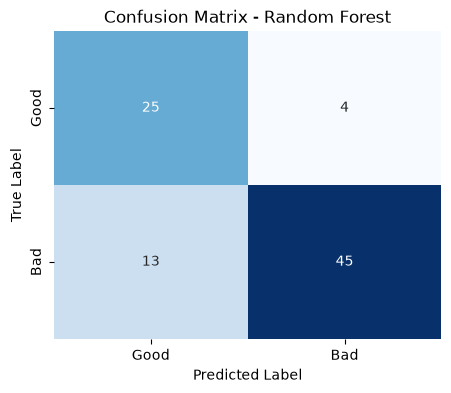

In [8]:
# Voorbeeld voor Model 1: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train) # Of X_train_scaled

evaluate_model(rf_model, X_test, y_test, model_name="Random Forest")

### Training and Evaluating the Logistic Regression Model

This step trains an unsupervised Logistic Regression model on the training data without using class labels. Logistic regression is a supervised machine learning method used to predict the probability of a categorical outcome. Here, the categories are good road and bad road. 

--- Evaluatie voor: Logistic Regression ---
Accuracy: 0.7701

Classification Report:
               precision    recall  f1-score   support

Good Road (0)       0.61      0.86      0.71        29
 Bad Road (1)       0.91      0.72      0.81        58

     accuracy                           0.77        87
    macro avg       0.76      0.79      0.76        87
 weighted avg       0.81      0.77      0.78        87



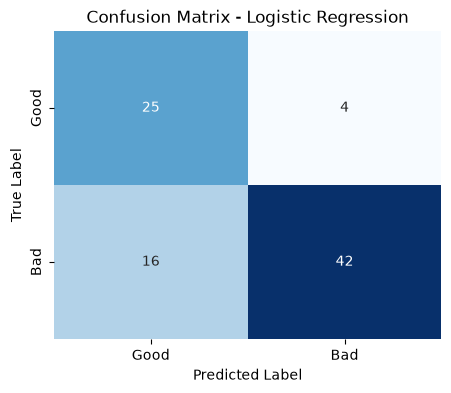

In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_scaled, y_train)
prediction = lr_model.predict(X_test_scaled)

evaluate_model(lr_model, X_test_scaled, y_test, model_name="Logistic Regression")

### Training and Evaluating the Support Vector Machine Model

This step trains a supervised SVM model. The Radial Basis Function (RBF) kernel is  used to handle complex, non-linearly separable data by mapping inputs into an infinite-dimensional space. The penalty induced by parameter C is a squared l2 penalty. The parameter Gamma = 'scale' standardly uses 1 / (n_features * X.var()) as value.


--- Evaluatie voor: SVM ---
Accuracy: 0.7816

Classification Report:
               precision    recall  f1-score   support

Good Road (0)       0.62      0.90      0.73        29
 Bad Road (1)       0.93      0.72      0.82        58

     accuracy                           0.78        87
    macro avg       0.78      0.81      0.77        87
 weighted avg       0.83      0.78      0.79        87



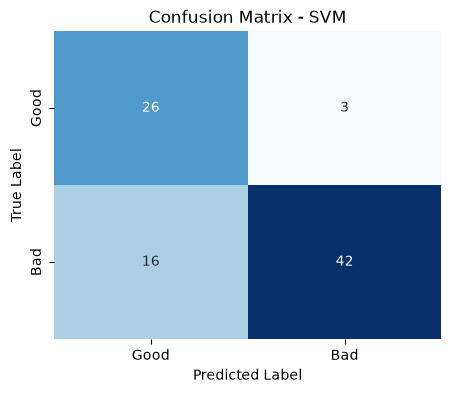

In [14]:
from sklearn.svm import SVC

# Kernel type is Radial Basis Function, C the regularization parameter standard to 1.0, gamma = 'scale' which standardly uses 1 / (n_features * X.var()) as value.
svm_model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

evaluate_model(svm_model, X_test_scaled, y_test, model_name="SVM")

### Training and Evaluating the Isolation Forest Model

This step trains an unsupervised Isolation Forest model on the training data without using class labels. The model identifies anomalies based on the contamination parameter, which estimates the proportion of outliers (bad roads) in the dataset. Predictions output `-1` for anomalies and `1` for normal instances, which are then remapped to match the binary target labels (`1` for bad roads and `0` for good roads). Finally, the model's performance is evaluated using accuracy, precision, recall, and f1-score.

In [10]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, accuracy_score

# Initialiseer en train het Isolation Forest zonder labels
# contamination is het geschatte percentage slechte wegen
iso_forest = IsolationForest(contamination=0.5, random_state=42)
iso_forest.fit(X_train)

# Voorspellen op de testset
# Isolation Forest geeft 1 voor normale data (goed) en -1 voor afwijkingen (slecht)
raw_preds = iso_forest.predict(X_test)

# Mappen naar correcte labels: -1 (outlier/slecht) wordt 1, en 1 (normaal/goed) wordt 0
y_pred_iso = [1 if p == -1 else 0 for p in raw_preds]

# Model evalueren 
print("--- Evaluatie Unsupervised: Isolation Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_iso):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_iso, target_names=['Good Road (0)', 'Bad Road (1)']))


--- Evaluatie Unsupervised: Isolation Forest ---
Accuracy: 0.4253

Classification Report:
               precision    recall  f1-score   support

Good Road (0)       0.11      0.10      0.11        29
 Bad Road (1)       0.57      0.59      0.58        58

     accuracy                           0.43        87
    macro avg       0.34      0.34      0.34        87
 weighted avg       0.41      0.43      0.42        87



### Training and Evaluating the Gaussian Mixture Model

This step trains a Gaussian Mixture Model on the training set. GMM is a probabilistic machine learning algorithm that assumes the data as a mixture of two Gaussian distributions, namely good and bad. Each window is assigned to the distribution with the highest probability. As the data is divided between two classes, a label flip option is used if the training data proves that to be logical (accuracy < 0.5). The derived mapping is then applied to the test set predictions. 

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (accuracy_score, classification_report,
                             adjusted_rand_score)


# Fit GMM (unsupervised: no y)
gmm = GaussianMixture(n_components=2, covariance_type='diag', n_init=10, random_state=42)
gmm.fit(X_train_scaled)

# Predict clusters for train and test
train_clusters = gmm.predict(X_train_scaled)
test_clusters = gmm.predict(X_test_scaled)

# Decide to flip for accuracy on the train data only, works only with two classes
train_acc = accuracy_score(y_train, train_clusters)
flip = train_acc < 0.5

# Apply that same decision to the test data
if flip:
    y_pred_gmm = 1 - test_clusters
else:
    y_pred_gmm = test_clusters

print("\n--- Evaluation Unsupervised: Gaussian Mixture Model (flip) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gmm):.4f}")
print(f"Adjusted Rand Index (test): {adjusted_rand_score(y_test, test_clusters):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_gmm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gmm,
                            target_names=['Good Road (0)', 'Bad Road (1)']))

Train accuracy before matching: 0.7270, so flip = False

--- Evaluation Unsupervised: Gaussian Mixture Model (flip) ---
Accuracy: 0.4023
Adjusted Rand Index (test): -0.0131
Confusion matrix:
[[24  5]
 [47 11]]

Classification Report:
               precision    recall  f1-score   support

Good Road (0)       0.34      0.83      0.48        29
 Bad Road (1)       0.69      0.19      0.30        58

     accuracy                           0.40        87
    macro avg       0.51      0.51      0.39        87
 weighted avg       0.57      0.40      0.36        87



### Training and Evaluating the Naive Bayes Classifier

This step trains a Gaussian Naive Bayes classifier on the training set. Since Naive Bayes relies on the assumption of conditional independence between features, it provides an interesting baseline to test against feature correlation in the accelerometer data. The model predicts road conditions on the test set, and its performance is evaluated using accuracy, precision, recall, and f1-score.

In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# Initialiseren en trainen
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Voorspellen en evalueren
y_pred_nb = nb_model.predict(X_test)
print("--- Evaluatie: Naive Bayes ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
print(classification_report(y_test, y_pred_nb, target_names=['Good Road (0)', 'Bad Road (1)']))

--- Evaluatie: Naive Bayes ---
Accuracy: 0.5747

               precision    recall  f1-score   support

Good Road (0)       0.43      0.83      0.56        29
 Bad Road (1)       0.84      0.45      0.58        58

     accuracy                           0.57        87
    macro avg       0.63      0.64      0.57        87
 weighted avg       0.70      0.57      0.58        87



### Training and Evaluating the DBSCAN Model

This step trains an unsupervised Density Based Scan (DBSCAN) Model. It groups data points that are closely packed and marks points in remote regions as noise. The radius from a data point and amount of points necessary define a densely packed area. First, the model makes a dbscan and assigns core points. Windows are then assigned to the closest core points, using nearest neighbours clustering, as no predicting method takes place. If the window doesn't qualify, it is labelled noise. The cluster labels are then mapped to road labels using the training set. 

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Fit DBSCAN on scaled train data (no y). eps defines radius of a neighbourhood, min_samples names min nr of data points within the radius to define it as a dense region.
# Based on iteration eps = 0.7 was chosen, trade-off between noise points and accuracy was considered.
db = DBSCAN(eps=0.7, min_samples=5)
train_clusters = db.fit_predict(X_train_scaled)

print("Clusters found:", sorted(set(train_clusters)))   
print("Noise points:", np.sum(train_clusters == -1))    # -1 = noise

# Assign test points to the nearest train core point within eps radius, otherwise pint is noise
core_points = db.components_
core_points_labels = train_clusters[db.core_sample_indices_]

# No predict method as clustering is the basis. Translate the core points to nearest neighbours. for every window, find the closest core point. Dist is the distance, idx is the id of the ocre point. 
nn = NearestNeighbors(n_neighbors=1).fit(core_points)
dist, idx = nn.kneighbors(X_test_scaled)
test_clusters = np.where(dist[:, 0] <= db.eps, core_points_labels[idx[:, 0]], -1) #Separator line

# Map clusters to labels using train majority vote labels
mapping = {c: y_train[train_clusters == c].mode()[0]
           for c in np.unique(train_clusters)}

# The prediction compares the clusters to road label in the training set. 
default_label = y_train.mode()[0]
y_pred_dbscan = np.array([mapping.get(c, default_label) for c in test_clusters])

# 4. Evaluate
print("--- Evaluation Unsupervised: DBSCAN ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dbscan):.4f}")
print(f"Adjusted Rand Index (test): {adjusted_rand_score(y_test, test_clusters):.4f}")
print(classification_report(y_test, y_pred_dbscan,
                            target_names=['Good Road (0)', 'Bad Road (1)']))

Clusters found: [np.int64(-1), np.int64(0)]
Noise points: 91
--- Evaluation Unsupervised: DBSCAN ---
Accuracy: 0.5517
Adjusted Rand Index (test): -0.0019
               precision    recall  f1-score   support

Good Road (0)       0.40      0.69      0.51        29
 Bad Road (1)       0.76      0.48      0.59        58

     accuracy                           0.55        87
    macro avg       0.58      0.59      0.55        87
 weighted avg       0.64      0.55      0.56        87



### Training and Evaluating the K-Means Clustering Model

This step trains an unsupervised K-Means clustering model with two clusters on the training features without utilizing class labels. Since clustering algorithms output arbitrary cluster identifiers rather than binary classes, a mapping strategy is implemented: the model evaluates cluster alignment on the training set to determine whether the cluster labels should be inverted. This derived mapping is then applied to the test set predictions, and the final classification performance is evaluated using accuracy, precision, recall, and f1-score.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 1. K-Means instellen en trainen op X_train
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train) 

# 2. Voorspellen op de TRAININGSSET om de mapping te bepalen
train_cluster_preds = kmeans.predict(X_train)

# Bepaal of we de clusters moeten omdraaien op basis van y_train
flip_clusters = np.mean(y_train == train_cluster_preds) < 0.5

# 3. Voorspellen op de testset
cluster_preds_test = kmeans.predict(X_test)
y_pred_kmeans = cluster_preds_test.copy()

# Pas exact dezelfde transformatie toe als nodig is
if flip_clusters:
    y_pred_kmeans = 1 - y_pred_kmeans  

# 4. Evalueren
print("--- Evaluatie Unsupervised: K-Means ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_kmeans):.4f}\n")
print(classification_report(y_test, y_pred_kmeans, target_names=['Good Road (0)', 'Bad Road (1)']))

--- Evaluatie Unsupervised: K-Means ---
Accuracy: 0.3793

               precision    recall  f1-score   support

Good Road (0)       0.35      0.97      0.51        29
 Bad Road (1)       0.83      0.09      0.16        58

     accuracy                           0.38        87
    macro avg       0.59      0.53      0.33        87
 weighted avg       0.67      0.38      0.27        87

